In [1]:
# =====  Setup, imports, CIFAR-10, splits, config =====

from google.colab import drive
drive.mount('/content/drive')

PROJ = "/content/drive/MyDrive/Imbalance"
%cd $PROJ

import os, json, math, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset, Dataset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

# Folders
for d in ["ckpts", "metrics", "figures", "splits"]:
    os.makedirs(os.path.join(PROJ, d), exist_ok=True)

# Repro
SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- Config ----------
CONFIG = {
    # cDCGAN
    "z_dim": 128,
    "g_channels": 128,
    "d_channels": 64,
    "gan_epochs": 40,
    "gan_batch_size": 128,
    "gan_lr": 2e-4,
    "gan_betas": (0.5, 0.999),

    # how many real images to match per class (max real count * ratio)
    "target_ratio": 1.0,   # 1.0 ~ full balance up to max class count in that split

    # classifier
    "cls_epochs": 50,
    "cls_batch_size": 128,
    "cls_lr": 0.1,
    "cls_weight_decay": 5e-4,
    "use_focal": False,         # to stay closer to your SNGAN CE classifier
    "focal_gamma": 1.5,

    # scenarios & models
    "include_lt": True,
    "include_ss": True,
    "include_as": True,
    "backbones": ["resnet18", "densenet121"],

    "num_workers": 2,
}
print(CONFIG)



Mounted at /content/drive
/content/drive/MyDrive/Imbalance
Device: cuda
{'z_dim': 128, 'g_channels': 128, 'd_channels': 64, 'gan_epochs': 40, 'gan_batch_size': 128, 'gan_lr': 0.0002, 'gan_betas': (0.5, 0.999), 'target_ratio': 1.0, 'cls_epochs': 50, 'cls_batch_size': 128, 'cls_lr': 0.1, 'cls_weight_decay': 0.0005, 'use_focal': False, 'focal_gamma': 1.5, 'include_lt': True, 'include_ss': True, 'include_as': True, 'backbones': ['resnet18', 'densenet121'], 'num_workers': 2}


In [2]:

# ---------- Transforms & data ----------
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),  # [-1,1]
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

train_data = datasets.CIFAR10("./dataset_cache", train=True, download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
num_classes = 10

# ---------- Load LT / SS / AS splits ----------
SPLITS = {}
for scn in ["lt","ss","as"]:
    p = os.path.join("splits", f"{scn}.json")
    if os.path.exists(p):
        with open(p) as f:
            data = json.load(f)
        SPLITS[scn] = {
            "indices": data["indices"],
            "counts": {int(k): int(v) for k,v in data["counts"].items()}
        }
        print(f"Loaded split '{scn.upper()}': {len(SPLITS[scn]['indices'])} images")
    else:
        print(f"WARNING: {p} not found.")

assert len(SPLITS) > 0, "No splits found. Run your data_split notebook first."

test_loader = DataLoader(
    test_data, batch_size=256, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

NUM_WORKERS = CONFIG["num_workers"]

Loaded split 'LT': 16191 images
Loaded split 'SS': 27500 images
Loaded split 'AS': 9500 images


In [3]:
# ===== cDCGAN Generator & Discriminator =====

class cDCGAN_G(nn.Module):
    def __init__(self, z_dim=128, num_classes=10, g_channels=128, embed_dim=50):
        super().__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes

        self.embed = nn.Embedding(num_classes, embed_dim)

        in_dim = z_dim + embed_dim
        self.fc = nn.Linear(in_dim, 4 * 4 * g_channels * 4)  # 4x4 spatial, big channel

        self.net = nn.Sequential(
            nn.BatchNorm2d(g_channels*4),
            nn.ReLU(True),
            nn.ConvTranspose2d(g_channels*4, g_channels*2, 4, 2, 1),  # 4 -> 8
            nn.BatchNorm2d(g_channels*2),
            nn.ReLU(True),
            nn.ConvTranspose2d(g_channels*2, g_channels, 4, 2, 1),    # 8 -> 16
            nn.BatchNorm2d(g_channels),
            nn.ReLU(True),
            nn.ConvTranspose2d(g_channels, 3, 4, 2, 1),               # 16 -> 32
            nn.Tanh(),  # [-1,1]
        )

    def forward(self, z, y):
        # z: [B, z_dim], y: [B]
        emb = self.embed(y)              # [B, embed_dim]
        h = torch.cat([z, emb], dim=1)   # [B, z_dim+embed_dim]
        h = self.fc(h)
        h = h.view(h.size(0), -1, 4, 4)  # [B, C, 4,4]
        x = self.net(h)                  # [B,3,32,32]
        return x


class cDCGAN_D(nn.Module):
    def __init__(self, num_classes=10, d_channels=64, embed_dim=50):
        super().__init__()
        self.num_classes = num_classes
        self.embed = nn.Embedding(num_classes, embed_dim)
        self.fc_label = nn.Linear(embed_dim, 32 * 32)

        # Input will be [B, 4, 32, 32] (3 channels image + 1 channel label map)
        self.net = nn.Sequential(
            nn.Conv2d(4, d_channels, 4, 2, 1),   # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(d_channels, d_channels*2, 4, 2, 1),  # 16 -> 8
            nn.BatchNorm2d(d_channels*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(d_channels*2, d_channels*4, 4, 2, 1),  # 8 -> 4
            nn.BatchNorm2d(d_channels*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(d_channels*4, 1, 4, 1, 0),  # 4 -> 1
        )

    def forward(self, x, y):
        # x: [B,3,32,32], y: [B]
        emb = self.embed(y)                      # [B, embed_dim]
        h = self.fc_label(emb)                   # [B, 32*32]
        h = h.view(h.size(0), 1, 32, 32)         # [B,1,32,32]
        x_in = torch.cat([x, h], dim=1)          # [B,4,32,32]
        out = self.net(x_in).view(-1)            # [B]
        return out  # logits (no sigmoid)


In [4]:
# =====  Train cDCGAN for a split & generate synthetic images =====

def make_split_loader(indices, batch_size, shuffle=True):
    subset = Subset(train_data, indices)
    return DataLoader(
        subset, batch_size=batch_size, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=True
    )


def train_cdcgan_for_split(indices, num_epochs=40):
    """
    Train cDCGAN on the subset of CIFAR-10 defined by `indices`.
    Returns the trained generator G.
    """
    loader = make_split_loader(indices, batch_size=CONFIG["gan_batch_size"], shuffle=True)

    G = cDCGAN_G(
        z_dim=CONFIG["z_dim"],
        num_classes=num_classes,
        g_channels=CONFIG["g_channels"]
    ).to(device)
    D = cDCGAN_D(
        num_classes=num_classes,
        d_channels=CONFIG["d_channels"]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optD = torch.optim.Adam(D.parameters(), lr=CONFIG["gan_lr"], betas=CONFIG["gan_betas"])
    optG = torch.optim.Adam(G.parameters(), lr=CONFIG["gan_lr"], betas=CONFIG["gan_betas"])

    for epoch in range(1, num_epochs+1):
        G.train(); D.train()
        d_running, g_running, n_batches = 0.0, 0.0, 0

        for real_imgs, labels in loader:
            real_imgs = real_imgs.to(device)
            labels    = labels.to(device)
            B = real_imgs.size(0)

            # Train Discriminator
            optD.zero_grad()
            real_logits = D(real_imgs, labels)
            real_targets = torch.ones_like(real_logits, device=device)
            d_loss_real = criterion(real_logits, real_targets)

            z = torch.randn(B, CONFIG["z_dim"], device=device)
            fake_imgs = G(z, labels)
            fake_logits = D(fake_imgs.detach(), labels)
            fake_targets = torch.zeros_like(fake_logits, device=device)
            d_loss_fake = criterion(fake_logits, fake_targets)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optD.step()

            # Train Generator
            optG.zero_grad()
            z = torch.randn(B, CONFIG["z_dim"], device=device)
            fake_imgs = G(z, labels)
            fake_logits = D(fake_imgs, labels)
            g_targets = torch.ones_like(fake_logits, device=device)
            g_loss = criterion(fake_logits, g_targets)
            g_loss.backward()
            optG.step()

            d_running += d_loss.item()
            g_running += g_loss.item()
            n_batches += 1

        d_epoch = d_running / max(1, n_batches)
        g_epoch = g_running / max(1, n_batches)

        if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
            print(f"[cDCGAN] Ep {epoch:03d}/{num_epochs} | "
                  f"D_loss={d_epoch:.4f} | G_loss={g_epoch:.4f}")

    return G


def generate_cdcgan_synthetic(G, counts, target_ratio=1.0):
    """
    Use trained G to generate synthetic images for each class until
    counts[c] reaches max_real * target_ratio.
    Returns tensors (syn_imgs, syn_labels).
    """
    G.eval()
    max_real = max(counts.values())
    target = int(max_real * target_ratio)
    print("Original counts:", counts)
    print("Target per class:", target)

    syn_imgs_list = []
    syn_labels_list = []

    with torch.no_grad():
        for c in range(num_classes):
            n_real = counts.get(c, 0)
            n_to_add = target - n_real
            if n_to_add <= 0:
                continue
            print(f"Class {c} ({class_labels[c]}): adding {n_to_add} synthetic samples")

            remaining = n_to_add
            while remaining > 0:
                b = min(remaining, 256)
                z = torch.randn(b, CONFIG["z_dim"], device=device)
                y = torch.full((b,), c, dtype=torch.long, device=device)
                fake = G(z, y).cpu()          # [b,3,32,32]
                syn_imgs_list.append(fake)
                syn_labels_list.append(torch.full((b,), c, dtype=torch.long))
                remaining -= b

    if len(syn_imgs_list) == 0:
        print("No synthetic images generated (already balanced?)")
        return None, None

    syn_imgs = torch.cat(syn_imgs_list, dim=0)
    syn_labels = torch.cat(syn_labels_list, dim=0)
    print("Total synthetic images generated:", syn_imgs.shape[0])
    return syn_imgs, syn_labels


class SyntheticImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.size(0)

    def __getitem__(self, idx):
        return self.images[idx], int(self.labels[idx])


In [5]:
# ===== ResNet18 / DenseNet121 + FocalLoss + metrics =====

def resnet18_cifar(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_model(backbone, num_classes=10):
    if backbone == "resnet18":
        return resnet18_cifar(num_classes)
    elif backbone == "densenet121":
        return densenet121_cifar(num_classes)
    else:
        raise ValueError(f"Unknown backbone {backbone}")


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.alpha, reduction="none")
        pt = torch.softmax(logits, dim=1).gather(1, target.view(-1,1)).squeeze(1).clamp_min(1e-8)
        loss = ((1-pt)**self.gamma) * ce
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    ys, ps = [], []
    for x,y in loader:
        x = x.to(device)
        pred = model(x).argmax(1).cpu().numpy()
        ys.append(y.numpy()); ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


def confusion_matrix_custom(y_true, y_pred, K=10):
    cm = np.zeros((K,K), dtype=np.int64)
    for t,p in zip(y_true, y_pred):
        cm[t,p] += 1
    return cm

def macro_f1(cm):
    prec = np.diag(cm) / np.clip(cm.sum(0), 1, None)
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    f1   = 2 * prec * rec / np.clip(prec+rec, 1e-12, None)
    return float(np.nanmean(f1))

def balanced_acc(cm):
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    return float(np.nanmean(rec))



SCENARIO: LT  (num train images = 16191)
Class counts: {0: 5000, 1: 3500, 2: 2449, 3: 1714, 4: 1200, 5: 840, 6: 588, 7: 411, 8: 288, 9: 201}

>>> Training cDCGAN on imbalanced split ...
[cDCGAN] Ep 001/40 | D_loss=0.6760 | G_loss=3.4482
[cDCGAN] Ep 005/40 | D_loss=0.2644 | G_loss=4.0439
[cDCGAN] Ep 010/40 | D_loss=0.2029 | G_loss=4.5991
[cDCGAN] Ep 015/40 | D_loss=0.1003 | G_loss=4.5685
[cDCGAN] Ep 020/40 | D_loss=0.1425 | G_loss=5.0028
[cDCGAN] Ep 025/40 | D_loss=0.1649 | G_loss=5.0882
[cDCGAN] Ep 030/40 | D_loss=0.1232 | G_loss=5.1018
[cDCGAN] Ep 035/40 | D_loss=0.0983 | G_loss=5.0047
[cDCGAN] Ep 040/40 | D_loss=0.0987 | G_loss=5.0510

>>> Generating cDCGAN synthetic images ...
Original counts: {0: 5000, 1: 3500, 2: 2449, 3: 1714, 4: 1200, 5: 840, 6: 588, 7: 411, 8: 288, 9: 201}
Target per class: 5000
Class 1 (automobile): adding 1500 synthetic samples
Class 2 (bird): adding 2551 synthetic samples
Class 3 (cat): adding 3286 synthetic samples
Class 4 (deer): adding 3800 synthetic sam

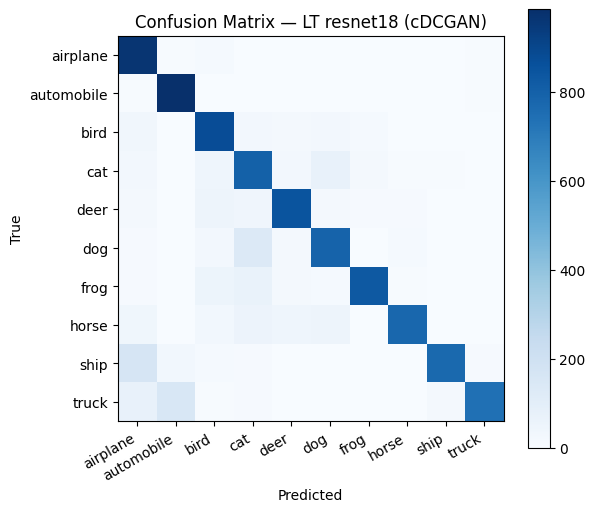

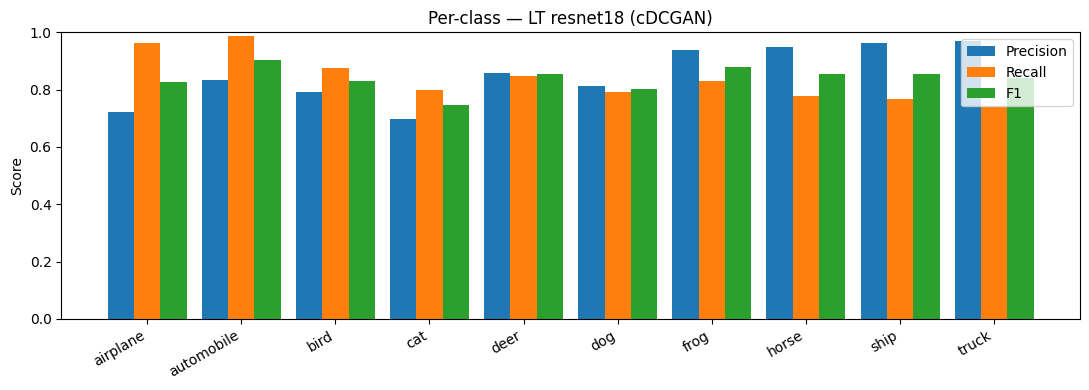


----------------------------------------------------------------------
LT | densenet121 | cDCGAN
[Epoch 001/50] train_loss=0.4933 acc=83.50% | val_loss=1.9058 acc=33.62%
[Epoch 005/50] train_loss=0.2690 acc=90.83% | val_loss=1.3266 acc=54.43%
[Epoch 010/50] train_loss=0.1904 acc=93.71% | val_loss=1.1537 acc=62.03%
[Epoch 015/50] train_loss=0.1694 acc=94.41% | val_loss=1.1748 acc=63.45%
[Epoch 020/50] train_loss=0.1421 acc=95.23% | val_loss=1.0253 acc=67.20%
[Epoch 025/50] train_loss=0.1203 acc=95.99% | val_loss=1.0241 acc=68.91%
[Epoch 030/50] train_loss=0.0963 acc=96.77% | val_loss=0.6432 acc=79.25%
[Epoch 035/50] train_loss=0.0616 acc=97.95% | val_loss=0.6769 acc=80.48%
[Epoch 040/50] train_loss=0.0285 acc=99.08% | val_loss=0.5682 acc=84.35%
[Epoch 045/50] train_loss=0.0066 acc=99.85% | val_loss=0.6082 acc=85.74%
[Epoch 050/50] train_loss=0.0031 acc=99.97% | val_loss=0.6272 acc=85.69%

TEST — Acc 85.84% | Macro-F1 85.98% | Balanced Acc 85.84%

--- Classification report: LT | densene

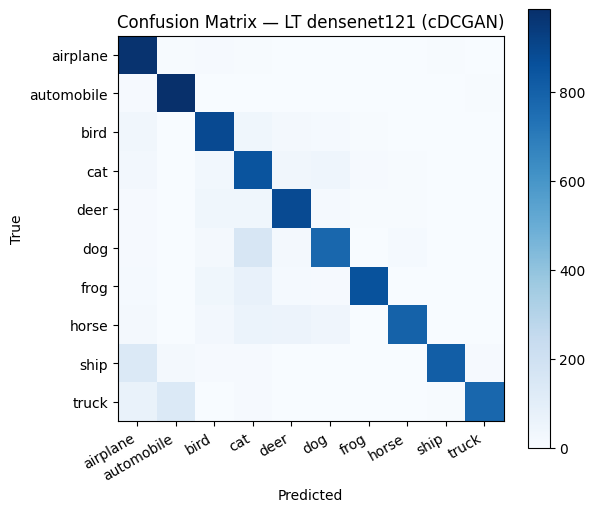

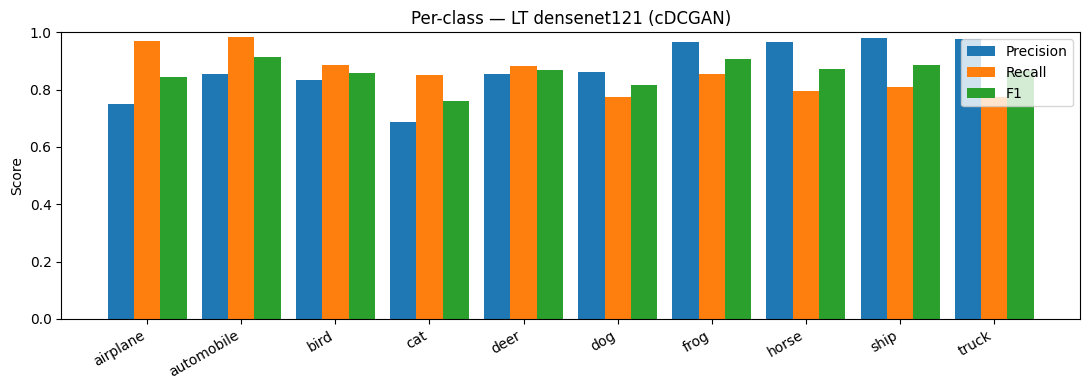


SCENARIO: SS  (num train images = 27500)
Class counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}

>>> Training cDCGAN on imbalanced split ...
[cDCGAN] Ep 001/40 | D_loss=0.4720 | G_loss=3.9162
[cDCGAN] Ep 005/40 | D_loss=0.1934 | G_loss=4.5156
[cDCGAN] Ep 010/40 | D_loss=0.1299 | G_loss=4.6892
[cDCGAN] Ep 015/40 | D_loss=0.1552 | G_loss=5.3042
[cDCGAN] Ep 020/40 | D_loss=0.1057 | G_loss=5.2328
[cDCGAN] Ep 025/40 | D_loss=0.1465 | G_loss=6.0836
[cDCGAN] Ep 030/40 | D_loss=0.0632 | G_loss=5.4536
[cDCGAN] Ep 035/40 | D_loss=0.0576 | G_loss=5.3988
[cDCGAN] Ep 040/40 | D_loss=0.0243 | G_loss=5.8240

>>> Generating cDCGAN synthetic images ...
Original counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Target per class: 5000
Class 5 (dog): adding 4500 synthetic samples
Class 6 (frog): adding 4500 synthetic samples
Class 7 (horse): adding 4500 synthetic samples
Class 8 (ship): adding 4500 synthetic samples


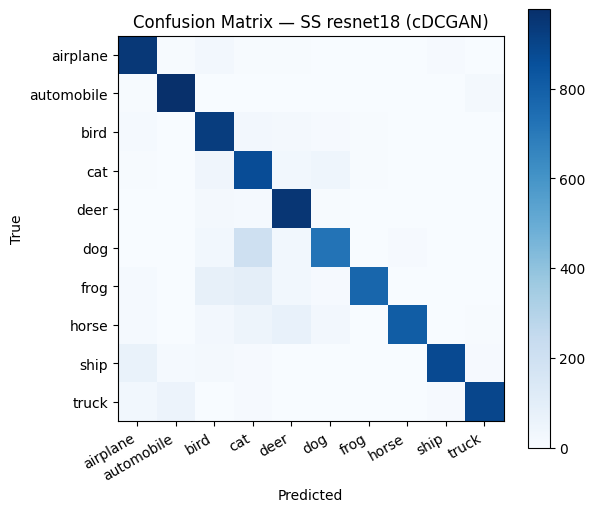

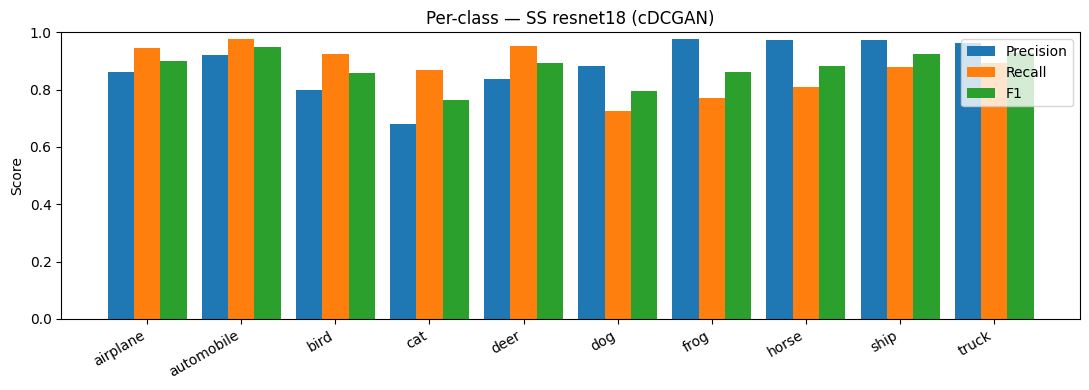


----------------------------------------------------------------------
SS | densenet121 | cDCGAN
[Epoch 001/50] train_loss=0.9665 acc=66.65% | val_loss=2.4059 acc=28.41%
[Epoch 005/50] train_loss=0.4902 acc=83.09% | val_loss=1.8440 acc=43.79%
[Epoch 010/50] train_loss=0.3066 acc=89.65% | val_loss=1.1908 acc=61.50%
[Epoch 015/50] train_loss=0.2454 acc=91.86% | val_loss=0.9972 acc=68.49%
[Epoch 020/50] train_loss=0.3225 acc=89.04% | val_loss=1.2909 acc=57.84%
[Epoch 025/50] train_loss=0.1958 acc=93.46% | val_loss=0.7002 acc=77.23%
[Epoch 030/50] train_loss=0.1455 acc=95.16% | val_loss=0.7518 acc=76.96%
[Epoch 035/50] train_loss=0.0990 acc=96.62% | val_loss=0.5940 acc=82.11%
[Epoch 040/50] train_loss=0.0476 acc=98.45% | val_loss=0.5929 acc=84.29%
[Epoch 045/50] train_loss=0.0108 acc=99.74% | val_loss=0.6539 acc=85.49%
[Epoch 050/50] train_loss=0.0051 acc=99.92% | val_loss=0.6482 acc=86.09%

TEST — Acc 86.18% | Macro-F1 86.16% | Balanced Acc 86.18%

--- Classification report: SS | densene

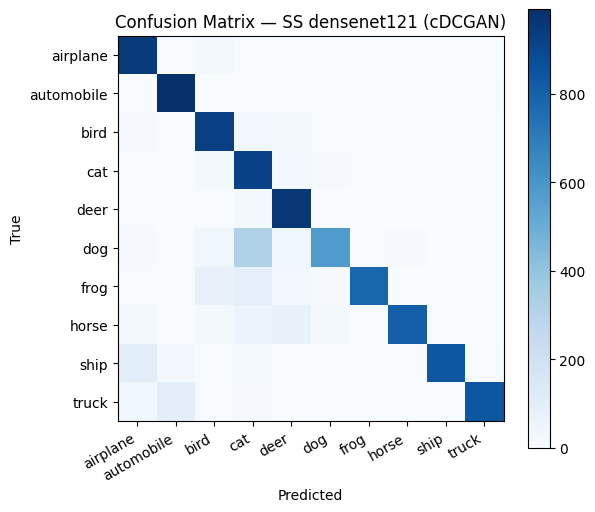

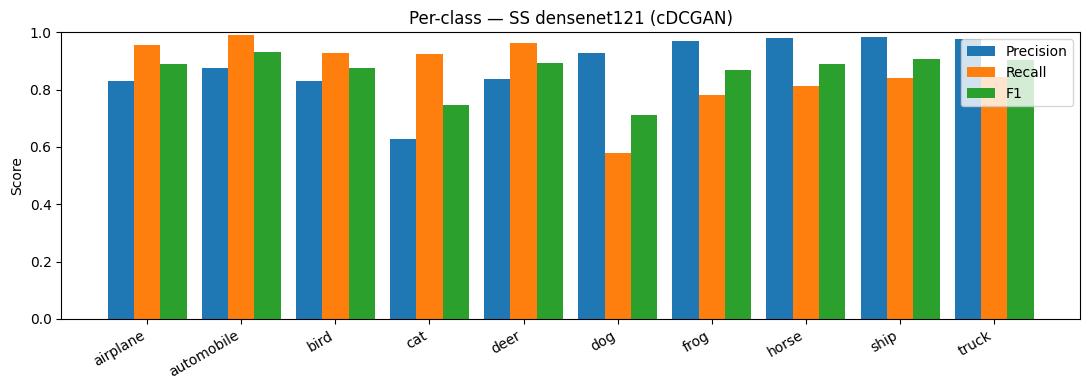


SCENARIO: AS  (num train images = 9500)
Class counts: {0: 5000, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}

>>> Training cDCGAN on imbalanced split ...
[cDCGAN] Ep 001/40 | D_loss=0.7536 | G_loss=3.5759
[cDCGAN] Ep 005/40 | D_loss=0.3258 | G_loss=4.2561
[cDCGAN] Ep 010/40 | D_loss=0.1966 | G_loss=4.6158
[cDCGAN] Ep 015/40 | D_loss=0.2574 | G_loss=4.8178
[cDCGAN] Ep 020/40 | D_loss=0.2173 | G_loss=5.0286
[cDCGAN] Ep 025/40 | D_loss=0.2615 | G_loss=4.3545
[cDCGAN] Ep 030/40 | D_loss=0.3746 | G_loss=3.7778
[cDCGAN] Ep 035/40 | D_loss=0.2215 | G_loss=3.7237
[cDCGAN] Ep 040/40 | D_loss=0.2848 | G_loss=3.1417

>>> Generating cDCGAN synthetic images ...
Original counts: {0: 5000, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Target per class: 5000
Class 1 (automobile): adding 4500 synthetic samples
Class 2 (bird): adding 4500 synthetic samples
Class 3 (cat): adding 4500 synthetic samples
Class 4 (deer): adding 4500 synthetic samples
Clas

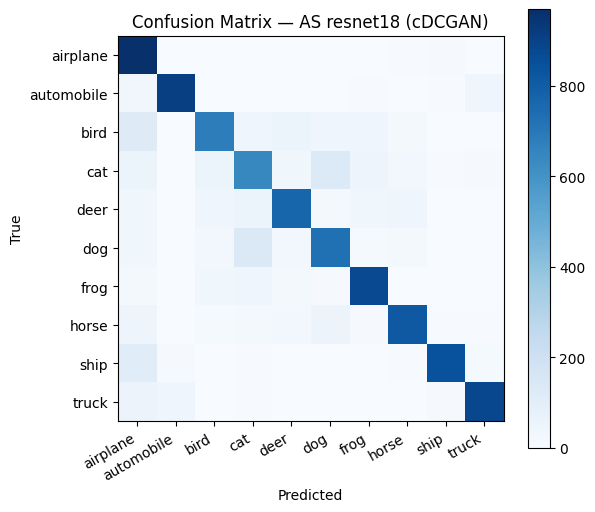

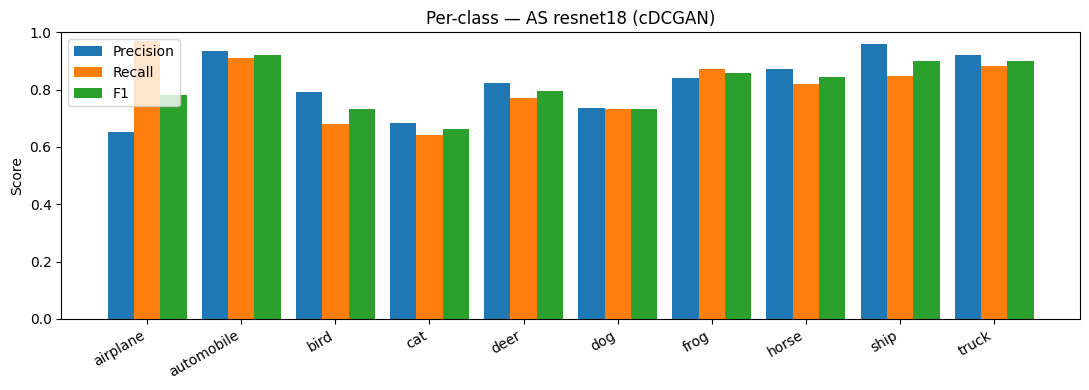


----------------------------------------------------------------------
AS | densenet121 | cDCGAN
[Epoch 001/50] train_loss=0.3239 acc=90.16% | val_loss=1.9160 acc=31.72%
[Epoch 005/50] train_loss=0.1637 acc=94.48% | val_loss=1.5517 acc=49.50%
[Epoch 010/50] train_loss=0.1284 acc=95.69% | val_loss=1.8186 acc=43.40%
[Epoch 015/50] train_loss=0.1119 acc=96.28% | val_loss=2.0465 acc=41.35%
[Epoch 020/50] train_loss=0.0978 acc=96.80% | val_loss=1.1718 acc=60.87%
[Epoch 025/50] train_loss=0.0827 acc=97.27% | val_loss=1.1974 acc=62.23%
[Epoch 030/50] train_loss=0.0643 acc=97.91% | val_loss=0.8350 acc=73.60%
[Epoch 035/50] train_loss=0.0428 acc=98.60% | val_loss=0.7836 acc=75.99%
[Epoch 040/50] train_loss=0.0183 acc=99.46% | val_loss=0.8650 acc=78.33%
[Epoch 045/50] train_loss=0.0043 acc=99.94% | val_loss=0.7780 acc=82.25%
[Epoch 050/50] train_loss=0.0027 acc=99.97% | val_loss=0.7619 acc=82.80%

TEST — Acc 82.93% | Macro-F1 83.04% | Balanced Acc 82.93%

--- Classification report: AS | densene

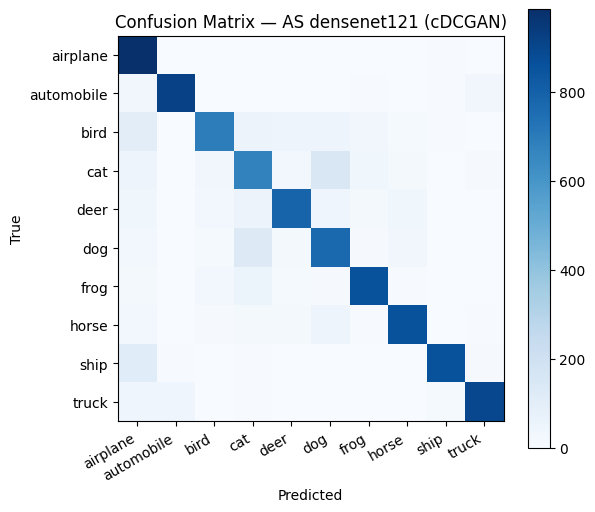

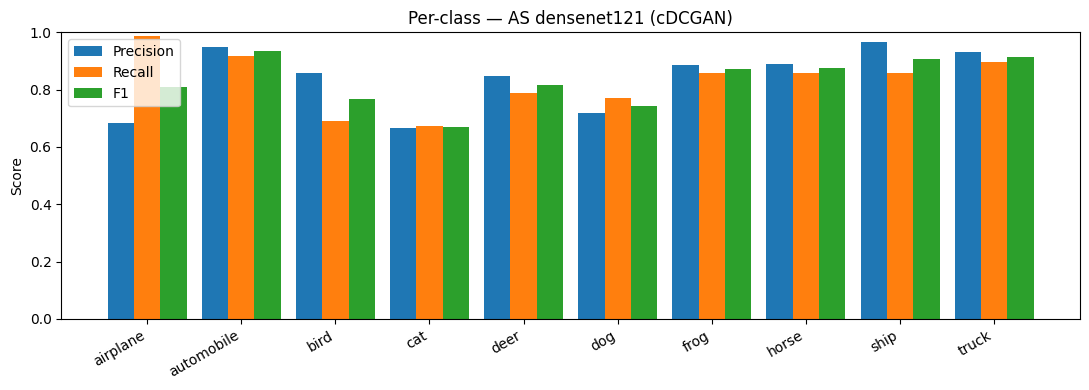


All cDCGAN runs finished.


In [6]:
# =====  Main cDCGAN loop over LT / SS / AS & both backbones =====

summary_rows = []

for scn_key, split in SPLITS.items():
    if (scn_key=="lt" and not CONFIG["include_lt"]) or \
       (scn_key=="ss" and not CONFIG["include_ss"]) or \
       (scn_key=="as" and not CONFIG["include_as"]):
        continue

    indices = split["indices"]
    counts  = split["counts"]

    print("\n" + "="*90)
    print(f"SCENARIO: {scn_key.upper()}  (num train images = {len(indices)})")
    print("Class counts:", counts)

    # -----Train cDCGAN -----
    print("\n>>> Training cDCGAN on imbalanced split ...")
    G = train_cdcgan_for_split(indices, num_epochs=CONFIG["gan_epochs"])

    # -----Generate synthetic images -----
    print("\n>>> Generating cDCGAN synthetic images ...")
    syn_imgs, syn_labels = generate_cdcgan_synthetic(
        G, counts, target_ratio=CONFIG["target_ratio"]
    )

    if syn_imgs is None:
        print("Skipping cDCGAN classifier (no synthetic images).")
        continue

    syn_dataset = SyntheticImageDataset(syn_imgs, syn_labels)
    train_subset_imbal = Subset(train_data, indices)
    train_dataset_cdcgan = ConcatDataset([train_subset_imbal, syn_dataset])

    train_loader_cdcgan = DataLoader(
        train_dataset_cdcgan,
        batch_size=CONFIG["cls_batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # -----Train classifier on real + synthetic for each backbone -----
    for backbone in CONFIG["backbones"]:
        tag = "cDCGAN"
        print("\n" + "-"*70)
        print(f"{scn_key.upper()} | {backbone} | {tag}")

        model = make_model(backbone, num_classes=num_classes).to(device)

        if CONFIG["use_focal"]:
            criterion = FocalLoss(gamma=CONFIG["focal_gamma"])
        else:
            criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=CONFIG["cls_lr"],
            momentum=0.9,
            weight_decay=CONFIG["cls_weight_decay"]
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["cls_epochs"]
        )

        best_acc = -1.0
        best_state = None

        for ep in range(1, CONFIG["cls_epochs"]+1):
            train_loss, train_acc = train_one_epoch(
                model, train_loader_cdcgan, criterion, optimizer
            )
            val_loss, val_acc = evaluate(model, test_loader, criterion)
            scheduler.step()

            if val_acc > best_acc:
                best_acc = val_acc
                best_state = {k: v.cpu() for k,v in model.state_dict().items()}

            if ep == 1 or ep % 5 == 0 or ep == CONFIG["cls_epochs"]:
                print(f"[Epoch {ep:03d}/{CONFIG['cls_epochs']}] "
                      f"train_loss={train_loss:.4f} acc={train_acc*100:.2f}% | "
                      f"val_loss={val_loss:.4f} acc={val_acc*100:.2f}%")

        # -----  Final test evaluation -----
        if best_state is not None:
            model.load_state_dict(best_state)

        y_true, y_pred = get_preds(model, test_loader)
        cm   = confusion_matrix_custom(y_true, y_pred, K=num_classes)
        acc  = (y_true == y_pred).mean()
        mF1  = macro_f1(cm)
        bAcc = balanced_acc(cm)

        print(f"\nTEST — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | "
              f"Balanced Acc {bAcc*100:.2f}%")

        # Classification report
        rep_txt = classification_report(
            y_true, y_pred, target_names=class_labels, digits=2
        )
        print(f"\n--- Classification report: {scn_key.upper()} | {backbone} | {tag} ---")
        print(rep_txt)

        # Save checkpoint & report
        ckpt_path = os.path.join(PROJ, "ckpts",
                                 f"{backbone}_{scn_key.upper()}_{tag}.pt")
        torch.save(model.state_dict(), ckpt_path)
        print("Saved checkpoint to:", ckpt_path)

        rep_path = os.path.join(PROJ, "metrics",
                                f"{backbone}_{scn_key.upper()}_{tag}_report.txt")
        with open(rep_path, "w") as f:
            f.write(rep_txt)
        print("Saved report to:", rep_path)

        # Confusion matrix figure
        plt.figure(figsize=(6.2,5.4))
        plt.imshow(cm, cmap="Blues", interpolation='nearest')
        plt.title(f"Confusion Matrix — {scn_key.upper()} {backbone} ({tag})")
        plt.colorbar()
        ticks = np.arange(len(class_labels))
        plt.xticks(ticks, class_labels, rotation=30, ha='right')
        plt.yticks(ticks, class_labels)
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout()
        fig_cm = os.path.join(PROJ, "figures",
                              f"cm_{backbone}_{scn_key.upper()}_{tag}.png")
        plt.savefig(fig_cm, dpi=180); plt.show()

        # Per-class bar chart
        prec, rec, f1, sup = precision_recall_fscore_support(
            y_true, y_pred, labels=range(num_classes), zero_division=0
        )
        x = np.arange(len(class_labels)); w = 0.28
        plt.figure(figsize=(11,4))
        plt.bar(x-w, prec, width=w, label='Precision')
        plt.bar(x,   rec,  width=w, label='Recall')
        plt.bar(x+w, f1,   width=w, label='F1')
        plt.ylim(0,1.0); plt.legend()
        plt.xticks(x, class_labels, rotation=30, ha='right')
        plt.ylabel("Score")
        plt.title(f"Per-class — {scn_key.upper()} {backbone} ({tag})")
        plt.tight_layout()
        fig_bar = os.path.join(PROJ, "figures",
                               f"perclass_{backbone}_{scn_key.upper()}_{tag}.png")
        plt.savefig(fig_bar, dpi=180); plt.show()

        summary_rows.append([
            scn_key.upper(), backbone, tag,
            round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)
        ])

print("\nAll cDCGAN runs finished.")


In [7]:
# =====  Summary table for cDCGAN =====

cols = ["Scenario","Model","Mode","Macro-F1 (%)","Balanced Acc (%)","Overall Acc (%)"]
df_cdcgan = pd.DataFrame(summary_rows, columns=cols).sort_values(
    ["Scenario","Model","Mode"]
)
display(df_cdcgan)

out_csv = os.path.join(PROJ, "metrics", "summary_cdcgan.csv")
df_cdcgan.to_csv(out_csv, index=False)
print("Saved cDCGAN summary to:", out_csv)


,Scenario,Model,Mode,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,cDCGAN,83.04,82.93,82.93
4,AS,resnet18,cDCGAN,81.26,81.21,81.21
1,LT,densenet121,cDCGAN,85.98,85.84,85.84
0,LT,resnet18,cDCGAN,83.90,83.81,83.81
3,SS,densenet121,cDCGAN,86.16,86.18,86.18
2,SS,resnet18,cDCGAN,87.55,87.46,87.46


Saved cDCGAN summary to: /content/drive/MyDrive/Imbalance/metrics/summary_cdcgan.csv
